## Categorical Independence: Chi-Square Tests

Run tests of independence to see if there is a real, mathematically significant relationship between the core categories: Work Mode vs. High Overtime and Overtime Threshold vs. Satisfaction Category

Import the necessary libraries.

In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

Load the cleaned HR dataset and print the column names to remember the variables in the dataset.

In [77]:
df = pd.read_csv("../data/employee_profiles_cleaned.csv")
print(df.columns.tolist())

['employee_id', 'age', 'salary', 'promotion_eligible', 'last_training_date', 'department', 'work_experience', 'projects_completed', 'hours_worked_weekly', 'work_mode', 'last_promotion_date', 'satisfaction_score', 'overtime_hours', 'graduation_year', 'educational_background']


### Work Mode versus Overtime Hours

Perform a Chi-square test to see whether work mode and overtime hours are truly independent.
First, categorize the overtime hours into two: High category (over 6 hrs) or not.

In [78]:
# Create a binary indicator for the 6-hour and up overtime hours
df['high_overtime'] = df['overtime_hours'] > 6

Create the contingency table (cross-tabulation).

In [79]:
contingency_table = pd.crosstab(df['work_mode'], df['high_overtime'])
print("--- Contingency Table ---")
print(contingency_table)

--- Contingency Table ---
high_overtime  False  True 
work_mode                  
hybrid            10     24
on-site            3      6
remote             5     15


Execute the **Chi-Square Test** for the null hypothesis that the overtime hours and work mode are related versus the alternative hypothesis that they are independent from each other.

In [80]:
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value:              {p_val:.4f}")
print(f"Degrees of Freedom:   {dof}")

--- Chi-Square Test Results ---
Chi-Square Statistic: 0.2368
p-value:              0.8884
Degrees of Freedom:   2


Interpret the results.

In [81]:
alpha = 0.05
if p_val < alpha:
    print("\nResult: Statistically Significant! Reject the null hypothesis.")
    print("There is a significant relationship between Work Mode and crossing the overtime cliff.")
else:
    print("\nResult: Not Statistically Significant. Fail to reject the null hypothesis.")
    print("Work Mode and Overtime work behaviors appear to be independent.")


Result: Not Statistically Significant. Fail to reject the null hypothesis.
Work Mode and Overtime work behaviors appear to be independent.


See if you can visually validate this result using a bar chart of the overtime hours categories by work mode.

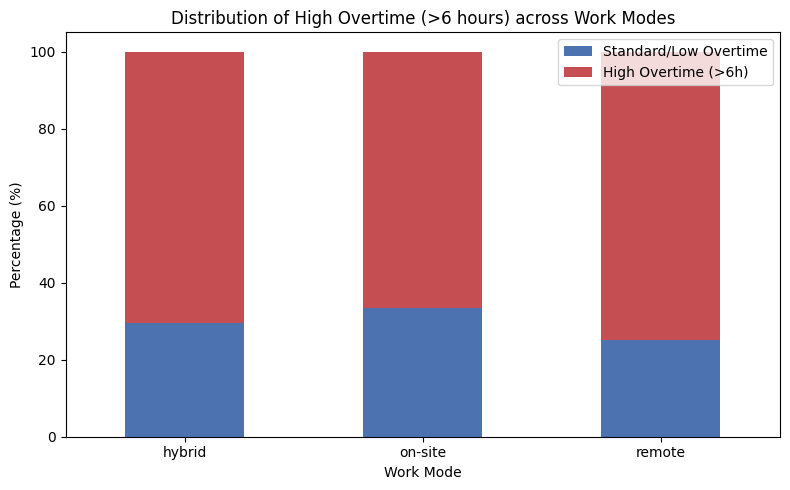

In [ ]:

contingency_table_pct = pd.crosstab(df['work_mode'], df['high_overtime'], normalize='index') * 100
contingency_table_pct.plot(kind='bar', stacked=True, color=['#4C72B0', '#C44E52'], figsize=(8,5))

plt.title('Distribution of High Overtime (>6 hours) across Work Modes')
plt.ylabel('Percentage (%)')
plt.xlabel('Work Mode')
plt.xticks(rotation=0)
plt.legend(['Standard/Low Overtime', 'High Overtime (>6h)'], loc='upper right')

plt.tight_layout()
plt.show()

High overtime hours percentages seem similar among the three different work modes.

### Satisfaction Scores versus Overtime Hours

In [122]:
# Define satisfaction score categories based on the given threshold
conditions = [
    df['satisfaction_score'] < 6,
    df['satisfaction_score'] == 6,
    df['satisfaction_score'] > 6
]

# Define the labels for each condition
categories = ['<6', '=6', '>6']

# Create the new categorical column
df['satisfaction_category'] = np.select(conditions, categories, default='Unknown')

In [123]:
contingency_table2 = pd.crosstab(df['high_overtime'], df['satisfaction_category'])
print("--- Contingency Table ---")
print(contingency_table2)

--- Contingency Table ---
satisfaction_category  <6  =6  >6
high_overtime                    
False                   5  10   3
True                   14  21  10


In [124]:
chi2, p_val, dof, expected = chi2_contingency(contingency_table2)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value:              {p_val:.4f}")
print(f"Degrees of Freedom:   {dof}")

--- Chi-Square Test Results ---
Chi-Square Statistic: 0.4461
p-value:              0.8001
Degrees of Freedom:   2


## Satisfaction Scores versus Departments : ANOVA

Use **One-Way ANOVA** Variance Testing to see if the differences in the mean satisfaction scores across different departments are statistically significant, or if the severe drop in HR is possibly the result of a small sample size.

Group the data by department for the ANOVA input by extracting the satisfaction scores for each specific department cohort.

In [134]:
for dept in df['department'].unique():
    scores = df[df['department'] == dept]['satisfaction_score'].values
    print(f"Department: {dept} (Total: {len(scores)})")
    print(scores)
    print("-" * 40)

Department: Finance (Total: 30)
[ 6.  6.  7.  6.  2.  7.  6.  6.  7.  3.  6.  6.  3.  9.  5.  1.  6.  4.
  6.  6.  6.  6. 10.  5. 10.  6.  6.  3.  1.  6.]
----------------------------------------
Department: Hr (Total: 6)
[3. 3. 6. 6. 1. 6.]
----------------------------------------
Department: Engineering (Total: 18)
[ 4.  3.  6. 10. 10.  6.  1.  8.  8.  6.  6.  6.  9.  6.  5.  8.  6.  9.]
----------------------------------------
Department: Marketing (Total: 9)
[6. 1. 2. 6. 6. 3. 6. 6. 6.]
----------------------------------------


Execute the One-Way ANOVA

In [141]:
groups = [df[df['department'] == dept]['satisfaction_score'] for dept in df['department'].unique()]
f_stat, p_val = f_oneway(*groups)

print("--- One-Way ANOVA Results ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"p-value:     {p_val:.4f}")

--- One-Way ANOVA Results ---
F-Statistic: 2.3495
p-value:     0.0816


Interpret the result.

In [142]:
# Interpretation of ANOVA results
alpha = 0.05
if p_val < alpha:
    print("\nResult: Statistically Significant! Reject the null hypothesis.")
    print("At least one department's satisfaction score distribution is significantly different from the others.")
else:
    print("\nResult: Not Statistically Significant. Fail to reject the null hypothesis.")
    print("The differences in satisfaction levels across departments could purely be due to random sample variance.")


Result: Not Statistically Significant. Fail to reject the null hypothesis.
The differences in satisfaction levels across departments could purely be due to random sample variance.


 Create the boxplot again to see how the distribution of satisfaction scores look by department.

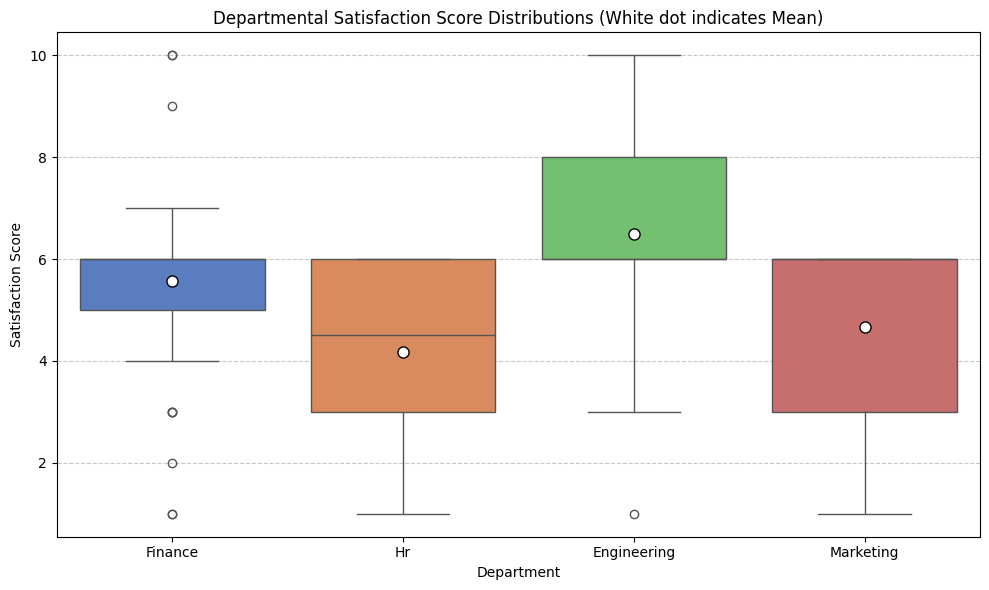

In [143]:
plt.figure(figsize=(10,6))
sns.boxplot(x='department',y='satisfaction_score',data=df, 
    hue='department',legend=False,palette='muted',showmeans=True, 
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.title('Departmental Satisfaction Score Distributions (White dot indicates Mean)')
plt.ylabel('Satisfaction Score')
plt.xlabel('Department')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Even though the median satisfaction score is lower than the median value of 6 and most of the scores in the marketing department are lower than the median, the sample size of both departments are much lower than that of fincance and engineering. It would be important to collect more data for HR and Marketing to gain more insight.Gathering the salary data for the discarded data is recommended, so that such a big amount is not removed from the data set and rerun the whole pipeline to see how the results are impacted.